# Pipeline Experimentations

Notebook structure:
- Cell 1-5: setup and reusable helpers
- Cell 6-9: instrumented pipeline + baseline functions
- Cell 10-13: orchestrator and CVAE hyperparameter sweeps
- Cell 14-15: robust comparison and report figures

This is designed to be truncatable: you can stop after any sweep and still keep usable artifacts.

In [1]:
import os
import sys
import gc
import math
import json
import random
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / 'database' / 'training_data.json'
EXPERIMENT_DIR = REPO_ROOT / 'experiments' / 'pipeline_experimentations'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

RUN_PROFILE = 'full'  # 'fast' or 'full'
RUN_ORCHESTRATOR_SWEEP = True
RUN_CVAE_SWEEP = True
RUN_BASELINE_COMPARISON = True
USE_ESM_BIOLOGIST = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    torch.random.manual_seed(SEED)
except Exception:
    pass

print(f'Repo root: {REPO_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Run profile: {RUN_PROFILE}')

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path exists: True
CUDA available: True
Run profile: full


In [2]:
from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.agent_v1.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.chemist.agent_v1.chemist_agent import ChemistAgent
from peptide_pipeline.orchestrator.orchestrator import Orchestrator
from peptide_pipeline.biologist.base import BaseBiologist

TARGET = {
    'dbaasp_id': 'DBAASPS_373',
    'sequence': 'KLFKRWKHLFR',
    'length': 11,
    'ph': None,
    'molecular_weight': 1558.9480000000003,
    'logp': -0.992100000000006,
    'net_charge': 5.0,
    'isoelectric_point': 12.18,
    'hydrophobicity': 1.05,
    'cathionicity': 6,
}

AA = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21
MAX_LEN = 14

class FallbackBiologist(BaseBiologist):
    def __init__(self, reference_peptide: str):
        self.reference_peptide = reference_peptide

    def score_peptides(self, peptides: List[str]) -> List[float]:
        if not peptides:
            return []
        ref_set = set(self.reference_peptide)
        denom = max(len(ref_set), 1)
        return [len(ref_set.intersection(set(p))) / denom for p in peptides]

    def predict_activity(self, peptides: List[str], context: Any = None) -> List[float]:
        if isinstance(context, str) and context.strip():
            previous = self.reference_peptide
            self.reference_peptide = context
            scores = self.score_peptides(peptides)
            self.reference_peptide = previous
            return scores
        return self.score_peptides(peptides)


def build_biologist(reference_peptide: str, score_temperature: float = 50.0):
    if USE_ESM_BIOLOGIST:
        try:
            from peptide_pipeline.biologist.esm_biologist_global_l2 import ESMBiologistGlobalL2
            return ESMBiologistGlobalL2(
                reference_peptide=reference_peptide,
                batch_size=16,
                score_temperature=score_temperature,
            )
        except Exception as e:
            print(f'ESM biologist unavailable, using fallback biologist: {e}')
    return FallbackBiologist(reference_peptide=reference_peptide)

/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def encode_one_hot_with_pad(sequences: List[str], max_len: int = MAX_LEN) -> torch.Tensor:
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x


def build_condition_tensor(dataframe: pd.DataFrame, condition_dim: int = 32) -> torch.Tensor:
    cond = torch.zeros(len(dataframe), condition_dim, dtype=torch.float32)
    cond[:, 0] = torch.tensor(dataframe['length'].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe['molecular_weight'].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe['net_charge'].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe['isoelectric_point'].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe['hydrophobicity'].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe['cathionicity'].values, dtype=torch.float32)
    cond[:, 6] = 0.5
    cond[:, 7] = torch.tensor(dataframe['logp'].values, dtype=torch.float32)
    cond[:, 8] = 0.0
    cond[:, 9] = 5.0
    cond[:, 10] = 5.0
    cond[:, 11] = 100.0
    return cond


loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        'sequence', 'length', 'ph', 'molecular_weight', 'logp',
        'net_charge', 'isoelectric_point', 'hydrophobicity', 'cathionicity'
    ],
    fillna_defaults={
        'length': 10,
        'ph': 7.0,
        'molecular_weight': 1500.0,
        'logp': 0.0,
        'net_charge': 0.0,
        'isoelectric_point': 7.0,
        'hydrophobicity': 0.0,
        'cathionicity': 0.0,
    },
    normalize_sequence=True,
    sequence_column='sequence',
    keep_standard_amino_acids_only=True,
)

df = loader.get_data().copy()
sequences = df['sequence'].tolist()
lengths = torch.tensor(df['length'].astype(int).values, dtype=torch.long)
x = encode_one_hot_with_pad(sequences, max_len=MAX_LEN)
conditions = build_condition_tensor(df, condition_dim=32)

print(f'Dataset rows: {len(df)}')
print(f'x shape: {tuple(x.shape)}')
print(f'conditions shape: {tuple(conditions.shape)}')
display(df.head(3))

Dataset rows: 4410
x shape: (4410, 294)
conditions shape: (4410, 32)


,sequence,length,ph,molecular_weight,logp,net_charge,isoelectric_point,hydrophobicity,cathionicity
0,KVVVKWVVKVVK,12,7.0,1648.291,5.6026,5.0,14.0,-1.07,4
1,LFIFFF,6,7.0,832.059,3.2860,1.0,14.0,-3.25,0
2,KAAAKWAAKAAK,12,7.0,1451.913,1.1499,5.0,14.0,0.33,4


In [4]:
def build_chemist_from_target(
    target: Dict[str, Any],
    width_scale: float = 1.0,
    length_min: float = 8.0,
    length_max: float = 14.0,
    length_weight: float = 1.0,
) -> ChemistAgent:
    ph = 7.0 if target['ph'] is None else float(target['ph'])
    target_length = float(target['length'])
    min_len = min(length_min, target_length)
    max_len = max(length_max, target_length)

    target_mw = float(target['molecular_weight'])
    mw_span = max(250.0, 0.35 * target_mw)
    mw_min = max(200.0, target_mw - mw_span)
    mw_max = target_mw + mw_span

    target_charge = float(target['net_charge'])
    charge_span = max(1.5, 0.5 * abs(target_charge))
    charge_min = max(0.0, target_charge - charge_span)
    charge_max = target_charge + charge_span

    target_ip = float(target['isoelectric_point'])
    ip_span = 2.5 * width_scale
    ip_min = max(3.0, target_ip - ip_span)
    ip_max = min(14.0, target_ip + ip_span)

    target_hydro = float(target['hydrophobicity'])
    hydro_span = 1.5 * width_scale
    hydro_min = target_hydro - hydro_span
    hydro_max = target_hydro + hydro_span

    target_logp = float(target['logp'])
    logp_span = 2.0 * width_scale
    logp_min = target_logp - logp_span
    logp_max = target_logp + logp_span

    return ChemistAgent(
        config=ChemistConfig(
            ph=ph,
            length=RangeTarget(min=min_len, max=max_len, target=target_length, weight=length_weight),
            molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=target_mw, weight=1.0),
            logp=RangeTarget(min=logp_min, max=logp_max, target=target_logp, weight=1.0),
            net_charge=RangeTarget(min=charge_min, max=charge_max, target=target_charge, weight=1.0),
            isoelectric_point=RangeTarget(min=ip_min, max=ip_max, target=target_ip, weight=1.0),
            hydrophobicity=RangeTarget(min=hydro_min, max=hydro_max, target=target_hydro, weight=1.0),
        )
    )


def model_cache_path(latent_dim: int, hidden_dim: int, epochs: int, lr: float) -> Path:
    lr_text = str(lr).replace('.', 'p')
    return EXPERIMENT_DIR / f'cvae_lat{latent_dim}_hid{hidden_dim}_ep{epochs}_lr{lr_text}.pth'


def get_or_train_cvae(latent_dim: int, hidden_dim: int, epochs: int, lr: float, kl_anneal_epochs: int, batch_size: int = 64) -> CVAEGenerator:
    model = CVAEGenerator(max_len=MAX_LEN, latent_dim=latent_dim, hidden_dim=hidden_dim, condition_dim=32)
    path = model_cache_path(latent_dim, hidden_dim, epochs, lr)

    if path.exists():
        model.load_model(str(path))
        return model

    device = model.device
    x_local = x.to(device)
    c_local = conditions.to(device)
    l_local = lengths.to(device)

    model.train_model(
        data=x_local,
        conditions=c_local,
        lengths=l_local,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
    )
    model.save_model(str(path))
    return model

In [5]:
def normalized_hamming(a: str, b: str) -> float:
    m = max(len(a), len(b), 1)
    a_pad = a.ljust(m, '-')
    b_pad = b.ljust(m, '-')
    return sum(ch1 != ch2 for ch1, ch2 in zip(a_pad, b_pad)) / m


def bigram_entropy(peptides: List[str]) -> float:
    counts: Dict[str, int] = {}
    total = 0
    for p in peptides:
        for i in range(max(len(p) - 1, 0)):
            bg = p[i : i + 2]
            counts[bg] = counts.get(bg, 0) + 1
            total += 1
    if total == 0:
        return 0.0
    probs = np.array([v / total for v in counts.values()], dtype=float)
    return float(-(probs * np.log2(np.clip(probs, 1e-12, 1.0))).sum())


def summarize_topk(rows: List[Dict[str, Any]]) -> Dict[str, float]:
    if not rows:
        return {
            'top1_score': 0.0,
            'topk_mean_score': 0.0,
            'validity_rate': 0.0,
            'unique_ratio': 0.0,
            'mean_pairwise_distance': 0.0,
            'bigram_entropy': 0.0,
        }

    peptides = [r['peptide'] for r in rows]
    scores = [float(r.get('combined_score', r.get('score', 0.0))) for r in rows]
    in_limits = [bool(r.get('in_limits', False)) for r in rows]

    dists = []
    for i in range(len(peptides)):
        for j in range(i + 1, len(peptides)):
            dists.append(normalized_hamming(peptides[i], peptides[j]))

    return {
        'top1_score': float(scores[0]),
        'topk_mean_score': float(np.mean(scores)),
        'validity_rate': float(np.mean(in_limits)),
        'unique_ratio': float(len(set(peptides)) / max(len(peptides), 1)),
        'mean_pairwise_distance': float(np.mean(dists) if dists else 0.0),
        'bigram_entropy': bigram_entropy(peptides),
    }

In [6]:
def safe_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def run_instrumented_pipeline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: BaseBiologist,
    final_target: Dict[str, Any],
    nb_iterations: int,
    nb_peptides: int,
    top_k: int,
    exploration_rate: float,
    random_parent_count: int,
) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    orchestrator = Orchestrator(generator=generator, chemist=chemist, biologist=biologist)
    target_constraints = {
        'length': final_target['length'],
        'molecular_weight': final_target['molecular_weight'],
        'logp': final_target['logp'],
        'net_charge': final_target['net_charge'],
        'isoelectric_point': final_target['isoelectric_point'],
        'hydrophobicity': final_target['hydrophobicity'],
        'cathionicity': final_target['cathionicity'],
    }

    top_rows = orchestrator.run(
        nb_iterations=nb_iterations,
        nb_peptides=nb_peptides,
        top_k=top_k,
        exploration_rate=exploration_rate,
        initial_peptide=final_target['sequence'],
        final_target=target_constraints,
        random_parent_count=random_parent_count,
    )

    # Reconstruct compact iteration trace from returned rows.
    trace_rows: List[Dict[str, Any]] = []
    if top_rows:
        by_iter = pd.DataFrame(top_rows).groupby('iteration', as_index=False)
        for _, chunk in by_iter:
            trace_rows.append(
                {
                    'iteration': int(chunk['iteration'].iloc[0]),
                    'returned_count': int(len(chunk)),
                    'best_combined_score': float(chunk['combined_score'].max()),
                    'mean_combined_score': float(chunk['combined_score'].mean()),
                    'validity_rate_returned': float(chunk['in_limits'].astype(float).mean()),
                }
            )

    return top_rows, pd.DataFrame(trace_rows).sort_values('iteration').reset_index(drop=True)


def run_non_agentic_baseline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: BaseBiologist,
    final_target: Dict[str, Any],
    budget: int,
    top_k: int,
) -> List[Dict[str, Any]]:
    constraints = {
        'length': final_target['length'],
        'molecular_weight': final_target['molecular_weight'],
        'logp': final_target['logp'],
        'net_charge': final_target['net_charge'],
        'isoelectric_point': final_target['isoelectric_point'],
        'hydrophobicity': final_target['hydrophobicity'],
        'cathionicity': final_target['cathionicity'],
    }

    peptides = generator.generate_peptides(count=budget, constraints=constraints)
    chem_rows = chemist.evaluate_peptides(peptides)
    valid_rows = [r for r in chem_rows if r.get('sequence')]
    bio_scores = biologist.score_peptides([r['sequence'] for r in valid_rows])

    rows = []
    for c_row, b_score in zip(valid_rows, bio_scores):
        chem_score = safe_float(c_row.get('score', 0.0))
        bio_score = safe_float(b_score)
        combined = 0.5 * (chem_score + bio_score)
        rows.append(
            {
                'peptide': c_row['sequence'],
                'score': combined,
                'combined_score': combined,
                'chemist_score': chem_score,
                'biologist_score': bio_score,
                'in_limits': bool(c_row.get('in_limits', False)),
                'properties': c_row.get('properties', {}),
                'iteration': 1,
            }
        )

    rows = sorted(
        rows,
        key=lambda x: (x['in_limits'], x['combined_score'], x['biologist_score'], x['chemist_score']),
        reverse=True,
    )
    dedup = {}
    for row in rows:
        if row['peptide'] not in dedup:
            dedup[row['peptide']] = row
    return list(dedup.values())[:top_k]

In [7]:
if RUN_PROFILE == 'fast':
    ORCHESTRATOR_GRID = [
        {'nb_iterations': 8, 'nb_peptides': 96, 'top_k': 10, 'exploration_rate': 0.10, 'random_parent_count': 2},
        {'nb_iterations': 10, 'nb_peptides': 128, 'top_k': 10, 'exploration_rate': 0.15, 'random_parent_count': 4},
        {'nb_iterations': 12, 'nb_peptides': 128, 'top_k': 10, 'exploration_rate': 0.20, 'random_parent_count': 4},
        {'nb_iterations': 14, 'nb_peptides': 160, 'top_k': 10, 'exploration_rate': 0.25, 'random_parent_count': 6},
        {'nb_iterations': 16, 'nb_peptides': 160, 'top_k': 10, 'exploration_rate': 0.30, 'random_parent_count': 6},
    ]
    CVAE_GRID = [
        {'latent_dim': 64, 'hidden_dim': 256, 'epochs': 140, 'lr': 1e-3, 'kl_anneal_epochs': 50},
        {'latent_dim': 96, 'hidden_dim': 256, 'epochs': 180, 'lr': 1e-3, 'kl_anneal_epochs': 60},
        {'latent_dim': 128, 'hidden_dim': 384, 'epochs': 220, 'lr': 7e-4, 'kl_anneal_epochs': 80},
    ]
    REPEATS = 3
    ORCH_SWEEP_REPEATS = 3
    CVAE_SWEEP_REPEATS = 3
else:
    ORCHESTRATOR_GRID = [
        {'nb_iterations': 12, 'nb_peptides': 128, 'top_k': 10, 'exploration_rate': 0.10, 'random_parent_count': 2},
        {'nb_iterations': 14, 'nb_peptides': 160, 'top_k': 10, 'exploration_rate': 0.15, 'random_parent_count': 4},
        {'nb_iterations': 16, 'nb_peptides': 192, 'top_k': 10, 'exploration_rate': 0.20, 'random_parent_count': 4},
        {'nb_iterations': 18, 'nb_peptides': 224, 'top_k': 10, 'exploration_rate': 0.25, 'random_parent_count': 6},
        {'nb_iterations': 20, 'nb_peptides': 256, 'top_k': 10, 'exploration_rate': 0.30, 'random_parent_count': 8},
        {'nb_iterations': 22, 'nb_peptides': 256, 'top_k': 10, 'exploration_rate': 0.35, 'random_parent_count': 10},
    ]
    CVAE_GRID = [
        {'latent_dim': 64, 'hidden_dim': 256, 'epochs': 160, 'lr': 1e-3, 'kl_anneal_epochs': 60},
        {'latent_dim': 96, 'hidden_dim': 256, 'epochs': 200, 'lr': 1e-3, 'kl_anneal_epochs': 80},
        {'latent_dim': 128, 'hidden_dim': 384, 'epochs': 220, 'lr': 7e-4, 'kl_anneal_epochs': 100},
        {'latent_dim': 160, 'hidden_dim': 384, 'epochs': 240, 'lr': 7e-4, 'kl_anneal_epochs': 120},
    ]
    REPEATS = 4
    ORCH_SWEEP_REPEATS = 3
    CVAE_SWEEP_REPEATS = 3

print(f'Orchestrator configs: {len(ORCHESTRATOR_GRID)}')
print(f'CVAE configs: {len(CVAE_GRID)}')
print(f'Pipeline vs baseline repeats: {REPEATS}')
print(f'Orchestrator sweep repeats/config: {ORCH_SWEEP_REPEATS}')
print(f'CVAE sweep repeats/config: {CVAE_SWEEP_REPEATS}')

Orchestrator configs: 6
CVAE configs: 4
Pipeline vs baseline repeats: 4
Orchestrator sweep repeats/config: 3
CVAE sweep repeats/config: 3


In [8]:
orchestrator_records = []
orchestrator_traces = []

if RUN_ORCHESTRATOR_SWEEP:
    fixed_cvae_cfg = {'latent_dim': 96, 'hidden_dim': 256, 'epochs': 200, 'lr': 1e-3, 'kl_anneal_epochs': 80}
    fixed_model = get_or_train_cvae(**fixed_cvae_cfg)

    # Reuse a single biologist across all orchestrator configs to avoid repeated model reload.
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    for cfg_id, run_cfg in enumerate(ORCHESTRATOR_GRID, start=1):
        total_generated = int(run_cfg['nb_iterations'] * run_cfg['nb_peptides'])
        per_cfg_metrics = []

        for rep in range(1, ORCH_SWEEP_REPEATS + 1):
            random.seed(SEED + 10_000 + 100 * cfg_id + rep)
            np.random.seed(SEED + 10_000 + 100 * cfg_id + rep)
            try:
                torch.random.manual_seed(SEED + 10_000 + 100 * cfg_id + rep)
            except Exception:
                pass

            chemist = build_chemist_from_target(TARGET)
            top_rows, trace_df = run_instrumented_pipeline(
                generator=fixed_model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=run_cfg['nb_iterations'],
                nb_peptides=run_cfg['nb_peptides'],
                top_k=run_cfg['top_k'],
                exploration_rate=run_cfg['exploration_rate'],
                random_parent_count=run_cfg['random_parent_count'],
            )

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)

            orchestrator_records.append(
                {
                    'config_id': cfg_id,
                    'repeat': rep,
                    'total_generated': total_generated,
                    **run_cfg,
                    **metrics,
                }
            )

            if not trace_df.empty:
                trace_df = trace_df.copy()
                trace_df['config_id'] = cfg_id
                trace_df['repeat'] = rep
                trace_df['total_generated'] = total_generated
                trace_df['exploration_rate'] = run_cfg['exploration_rate']
                orchestrator_traces.append(trace_df)

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        print(
            f"[orchestrator cfg {cfg_id}] budget={total_generated} "
            f"top1_mean={np.mean(top1_vals):.4f} top1_std={np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0:.4f}"
        )

orchestrator_raw_df = pd.DataFrame(orchestrator_records)
orchestrator_trace_df = pd.concat(orchestrator_traces, ignore_index=True) if orchestrator_traces else pd.DataFrame()
orchestrator_results_df = pd.DataFrame()

if not orchestrator_raw_df.empty:
    orchestrator_results_df = orchestrator_raw_df.groupby(
        ['config_id', 'total_generated', 'nb_iterations', 'nb_peptides', 'top_k', 'exploration_rate', 'random_parent_count'],
        as_index=False,
    ).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'bigram_entropy': ['mean', 'std'],
    })
    orchestrator_results_df.columns = ['_'.join(c).strip('_') for c in orchestrator_results_df.columns]
    orchestrator_results_df = orchestrator_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean', 'mean_pairwise_distance_mean'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(orchestrator_results_df)
display(orchestrator_raw_df.head(20))
display(orchestrator_trace_df.head(20))

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1468.05it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[orchestrator cfg 1] budget=1536 top1_mean=0.8789 top1_std=0.0050
[orchestrator cfg 2] budget=2240 top1_mean=0.8828 top1_std=0.0040
[orchestrator cfg 3] budget=3072 top1_mean=0.8803 top1_std=0.0018
[orchestrator cfg 4] budget=4032 top1_mean=0.8852 top1_std=0.0044
[orchestrator cfg 5] budget=5120 top1_mean=0.8841 top1_std=0.0023
[orchestrator cfg 6] budget=5632 top1_mean=0.8837 top1_std=0.0018


,config_id,total_generated,nb_iterations,nb_peptides,top_k,exploration_rate,random_parent_count,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std
0,4,4032,18,224,10,0.25,6,0.885196,0.004357,0.878905,0.002101,1.0,0.0,1.0,0.0,0.680808,0.056313,4.601384,0.036491
1,5,5120,20,256,10,0.30,8,0.884094,0.002325,0.879768,0.001249,1.0,0.0,1.0,0.0,0.681481,0.096766,4.678911,0.070201
2,6,5632,22,256,10,0.35,10,0.883695,0.001837,0.879375,0.001353,1.0,0.0,1.0,0.0,0.762963,0.016329,4.844702,0.061092
3,2,2240,14,160,10,0.15,4,0.882765,0.004045,0.876200,0.002242,1.0,0.0,1.0,0.0,0.757576,0.006998,4.791410,0.084518
4,3,3072,16,192,10,0.20,4,0.880311,0.001788,0.876341,0.000753,1.0,0.0,1.0,0.0,0.715825,0.015692,4.760728,0.197253
5,1,1536,12,128,10,0.10,2,0.878937,0.004985,0.874749,0.003835,1.0,0.0,1.0,0.0,0.687542,0.060076,4.740304,0.062377


,config_id,repeat,total_generated,nb_iterations,nb_peptides,top_k,exploration_rate,random_parent_count,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,1,1536,12,128,10,0.10,2,0.879244,0.874854,1.0,1.0,0.678788,4.742914
1,1,2,1536,12,128,10,0.10,2,0.883761,0.878530,1.0,1.0,0.632323,4.676664
2,1,3,1536,12,128,10,0.10,2,0.873805,0.870863,1.0,1.0,0.751515,4.801335
3,2,1,2240,14,160,10,0.15,4,0.887390,0.878547,1.0,1.0,0.753535,4.868724
4,2,2,2240,14,160,10,0.15,4,0.881017,0.875973,1.0,1.0,0.753535,4.804331
5,2,3,2240,14,160,10,0.15,4,0.879887,0.874080,1.0,1.0,0.765657,4.701175
6,3,1,3072,16,192,10,0.20,4,0.879125,0.876266,1.0,1.0,0.703030,4.538962
7,3,2,3072,16,192,10,0.20,4,0.882367,0.875629,1.0,1.0,0.711111,4.916595
8,3,3,3072,16,192,10,0.20,4,0.879441,0.877129,1.0,1.0,0.733333,4.826628
9,4,1,4032,18,224,10,0.25,6,0.886021,0.880495,1.0,1.0,0.745455,4.605561


,iteration,returned_count,best_combined_score,mean_combined_score,validity_rate_returned,config_id,repeat,total_generated,exploration_rate
0,2,2,0.874122,0.873165,1.0,1,1,1536,0.1
1,3,1,0.874026,0.874026,1.0,1,1,1536,0.1
2,5,1,0.877885,0.877885,1.0,1,1,1536,0.1
3,6,1,0.876366,0.876366,1.0,1,1,1536,0.1
4,8,2,0.879244,0.878625,1.0,1,1,1536,0.1
5,9,1,0.870157,0.870157,1.0,1,1,1536,0.1
6,11,2,0.874662,0.873261,1.0,1,1,1536,0.1
7,1,3,0.883761,0.881702,1.0,1,2,1536,0.1
8,2,2,0.877844,0.877050,1.0,1,2,1536,0.1
9,4,1,0.877315,0.877315,1.0,1,2,1536,0.1


In [9]:
cvae_records = []

if RUN_CVAE_SWEEP:
    default_run = ORCHESTRATOR_GRID[1]
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    for cfg_id, cvae_cfg in enumerate(CVAE_GRID, start=1):
        per_cfg_metrics = []

        for rep in range(1, CVAE_SWEEP_REPEATS + 1):
            random.seed(SEED + 20_000 + 100 * cfg_id + rep)
            np.random.seed(SEED + 20_000 + 100 * cfg_id + rep)
            try:
                torch.random.manual_seed(SEED + 20_000 + 100 * cfg_id + rep)
            except Exception:
                pass

            model = get_or_train_cvae(**cvae_cfg)
            chemist = build_chemist_from_target(TARGET)

            top_rows, trace_df = run_instrumented_pipeline(
                generator=model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=default_run['nb_iterations'],
                nb_peptides=default_run['nb_peptides'],
                top_k=default_run['top_k'],
                exploration_rate=default_run['exploration_rate'],
                random_parent_count=default_run['random_parent_count'],
            )

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)

            cvae_records.append({'cvae_cfg_id': cfg_id, 'repeat': rep, **cvae_cfg, **metrics})

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        print(
            f"[cvae cfg {cfg_id}] top1_mean={np.mean(top1_vals):.4f} "
            f"top1_std={np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0:.4f}"
        )

cvae_raw_df = pd.DataFrame(cvae_records)
cvae_results_df = pd.DataFrame()
if not cvae_raw_df.empty:
    cvae_results_df = cvae_raw_df.groupby(
        ['cvae_cfg_id', 'latent_dim', 'hidden_dim', 'epochs', 'lr', 'kl_anneal_epochs'],
        as_index=False,
    ).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'bigram_entropy': ['mean', 'std'],
    })
    cvae_results_df.columns = ['_'.join(c).strip('_') for c in cvae_results_df.columns]
    cvae_results_df = cvae_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean', 'mean_pairwise_distance_mean'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(cvae_results_df)
display(cvae_raw_df.head(20))

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1515.42it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[cvae cfg 1] top1_mean=0.8859 top1_std=0.0043
[cvae cfg 2] top1_mean=0.8819 top1_std=0.0018
[cvae cfg 3] top1_mean=0.8784 top1_std=0.0019
[cvae cfg 4] top1_mean=0.8796 top1_std=0.0015


,cvae_cfg_id,latent_dim,hidden_dim,epochs,lr,kl_anneal_epochs,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std
0,1,64,256,160,0.0010,60,0.885871,0.004330,0.880431,0.001891,1.0,0.0,1.0,0.0,0.735354,0.063660,4.596475,0.175878
1,2,96,256,200,0.0010,80,0.881934,0.001790,0.875612,0.001361,1.0,0.0,1.0,0.0,0.734007,0.040873,4.743655,0.103546
2,4,160,384,240,0.0007,120,0.879611,0.001490,0.873646,0.000548,1.0,0.0,1.0,0.0,0.756902,0.035703,4.736852,0.194025
3,3,128,384,220,0.0007,100,0.878443,0.001863,0.872616,0.001646,1.0,0.0,1.0,0.0,0.735354,0.025232,4.849992,0.172201


,cvae_cfg_id,repeat,latent_dim,hidden_dim,epochs,lr,kl_anneal_epochs,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,1,64,256,160,0.0010,60,0.881637,0.878387,1.0,1.0,0.733333,4.690790
1,1,2,64,256,160,0.0010,60,0.885684,0.880789,1.0,1.0,0.800000,4.705079
2,1,3,64,256,160,0.0010,60,0.890291,0.882117,1.0,1.0,0.672727,4.393557
3,2,1,96,256,200,0.0010,80,0.880932,0.876073,1.0,1.0,0.686869,4.775596
4,2,2,96,256,200,0.0010,80,0.880870,0.874081,1.0,1.0,0.755556,4.827467
5,2,3,96,256,200,0.0010,80,0.884001,0.876682,1.0,1.0,0.759596,4.627901
6,3,1,128,384,220,0.0007,100,0.876495,0.871096,1.0,1.0,0.727273,5.003563
7,3,2,128,384,220,0.0007,100,0.878625,0.872388,1.0,1.0,0.715152,4.663822
8,3,3,128,384,220,0.0007,100,0.880209,0.874364,1.0,1.0,0.763636,4.882592
9,4,1,160,384,240,0.0007,120,0.878148,0.873362,1.0,1.0,0.739394,4.643403


In [10]:
comparison_rows = []
best_cfg = CVAE_GRID[0] if not ('cvae_results_df' in globals() and not cvae_results_df.empty) else cvae_results_df.iloc[0].to_dict()

chosen_latent = int(best_cfg['latent_dim'])
chosen_hidden = int(best_cfg['hidden_dim'])
chosen_epochs = int(best_cfg['epochs'])
chosen_lr = float(best_cfg['lr'])
chosen_kl = int(best_cfg['kl_anneal_epochs'])

if RUN_BASELINE_COMPARISON:
    chosen_model = get_or_train_cvae(
        latent_dim=chosen_latent,
        hidden_dim=chosen_hidden,
        epochs=chosen_epochs,
        lr=chosen_lr,
        kl_anneal_epochs=chosen_kl,
    )

    base_orch = ORCHESTRATOR_GRID[1]
    budget = int(base_orch['nb_iterations'] * base_orch['nb_peptides'])
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    for rep in range(1, REPEATS + 1):
        random.seed(SEED + rep)
        np.random.seed(SEED + rep)
        try:
            torch.random.manual_seed(SEED + rep)
        except Exception:
            pass

        chemist = build_chemist_from_target(TARGET)

        pipe_rows, _ = run_instrumented_pipeline(
            generator=chosen_model,
            chemist=chemist,
            biologist=biologist,
            final_target=TARGET,
            nb_iterations=base_orch['nb_iterations'],
            nb_peptides=base_orch['nb_peptides'],
            top_k=base_orch['top_k'],
            exploration_rate=base_orch['exploration_rate'],
            random_parent_count=base_orch['random_parent_count'],
        )

        baseline_rows = run_non_agentic_baseline(
            generator=chosen_model,
            chemist=chemist,
            biologist=biologist,
            final_target=TARGET,
            budget=budget,
            top_k=base_orch['top_k'],
        )

        pipe_metrics = summarize_topk(pipe_rows)
        base_metrics = summarize_topk(baseline_rows)

        comparison_rows.append({'repeat': rep, 'method': 'pipeline', **pipe_metrics})
        comparison_rows.append({'repeat': rep, 'method': 'non_agentic_baseline', **base_metrics})

comparison_df = pd.DataFrame(comparison_rows)
comparison_summary_df = pd.DataFrame()
if not comparison_df.empty:
    comparison_summary_df = comparison_df.groupby('method', as_index=False).agg({
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'unique_ratio': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
        'bigram_entropy': ['mean', 'std'],
    })
    comparison_summary_df.columns = ['_'.join(col).strip('_') for col in comparison_summary_df.columns.values]

display(comparison_df)
display(comparison_summary_df)

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1057.17it/s, Materializing param=encoder.layer.11.output.dense.weight]                     
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,repeat,method,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,pipeline,0.879869,0.874592,1.0,1.0,0.765657,4.712369
1,1,non_agentic_baseline,0.814937,0.810156,1.0,1.0,0.797778,4.525365
2,2,pipeline,0.884973,0.881773,1.0,1.0,0.795960,4.771860
3,2,non_agentic_baseline,0.834660,0.821357,1.0,1.0,0.671111,4.610382
4,3,pipeline,0.883746,0.878406,1.0,1.0,0.787879,4.660078
5,3,non_agentic_baseline,0.827326,0.816126,1.0,1.0,0.657778,4.677871
6,4,pipeline,0.877434,0.873605,1.0,1.0,0.610101,4.727725
7,4,non_agentic_baseline,0.838980,0.814928,1.0,1.0,0.775556,4.912097


,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std
0,non_agentic_baseline,0.828976,0.010523,0.815642,0.004601,1.0,0.0,1.0,0.0,0.725556,0.071354,4.681429,0.165956
1,pipeline,0.881506,0.003478,0.877094,0.003744,1.0,0.0,1.0,0.0,0.739899,0.087475,4.718008,0.046123


In [11]:
# Length-compression study: can we keep quality with shorter target peptides?
length_sweep_rows = []

if RUN_BASELINE_COMPARISON:
    if 'chosen_model' not in globals():
        fallback_cfg = cvae_results_df.iloc[0].to_dict() if ('cvae_results_df' in globals() and not cvae_results_df.empty) else CVAE_GRID[0]
        chosen_model = get_or_train_cvae(
            latent_dim=int(fallback_cfg['latent_dim']),
            hidden_dim=int(fallback_cfg['hidden_dim']),
            epochs=int(fallback_cfg['epochs']),
            lr=float(fallback_cfg['lr']),
            kl_anneal_epochs=int(fallback_cfg['kl_anneal_epochs']),
        )

    base_run = ORCHESTRATOR_GRID[1] if len(ORCHESTRATOR_GRID) > 1 else ORCHESTRATOR_GRID[0]
    length_candidates = [7, 8, 9, 10, int(TARGET['length'])]
    length_candidates = sorted(set([l for l in length_candidates if 6 <= l <= MAX_LEN]))
    length_repeats = max(3, REPEATS)

    biologist_len = build_biologist(TARGET['sequence'], score_temperature=50.0)
    original_len = float(TARGET['length'])

    for target_len in length_candidates:
        ratio = float(target_len) / max(original_len, 1.0)
        compressed_target = dict(TARGET)
        compressed_target['length'] = int(target_len)

        # Scale length-dependent target properties so short peptides are not unfairly impossible.
        compressed_target['molecular_weight'] = float(TARGET['molecular_weight']) * ratio
        compressed_target['net_charge'] = max(1.0, float(TARGET['net_charge']) * ratio)

        width_scale = 1.0 + (0.2 if target_len < TARGET['length'] else 0.0)
        chemist_len = build_chemist_from_target(
            compressed_target,
            width_scale=width_scale,
            length_min=max(6.0, float(target_len) - 1.0),
            length_max=min(float(MAX_LEN), float(target_len) + 1.0),
            length_weight=1.2,
        )

        for rep in range(1, length_repeats + 1):
            random.seed(SEED + 100 * target_len + rep)
            np.random.seed(SEED + 100 * target_len + rep)
            try:
                torch.random.manual_seed(SEED + 100 * target_len + rep)
            except Exception:
                pass

            top_rows, _ = run_instrumented_pipeline(
                generator=chosen_model,
                chemist=chemist_len,
                biologist=biologist_len,
                final_target=compressed_target,
                nb_iterations=base_run['nb_iterations'],
                nb_peptides=base_run['nb_peptides'],
                top_k=base_run['top_k'],
                exploration_rate=base_run['exploration_rate'],
                random_parent_count=base_run['random_parent_count'],
            )

            metrics = summarize_topk(top_rows)
            realized_lengths = [
                float(r.get('properties', {}).get('length', len(r.get('peptide', ''))))
                for r in top_rows
            ]
            mean_realized_len = float(np.mean(realized_lengths)) if realized_lengths else 0.0

            length_sweep_rows.append(
                {
                    'target_length': int(target_len),
                    'repeat': rep,
                    'mean_realized_length': mean_realized_len,
                    'top1_score': metrics['top1_score'],
                    'topk_mean_score': metrics['topk_mean_score'],
                    'validity_rate': metrics['validity_rate'],
                    'mean_pairwise_distance': metrics['mean_pairwise_distance'],
                }
            )

length_sweep_df = pd.DataFrame(length_sweep_rows)
length_sweep_summary_df = pd.DataFrame()
if not length_sweep_df.empty:
    length_sweep_summary_df = length_sweep_df.groupby('target_length', as_index=False).agg({
        'mean_realized_length': ['mean', 'std'],
        'top1_score': ['mean', 'std'],
        'topk_mean_score': ['mean', 'std'],
        'validity_rate': ['mean', 'std'],
        'mean_pairwise_distance': ['mean', 'std'],
    })
    length_sweep_summary_df.columns = ['_'.join(c).strip('_') for c in length_sweep_summary_df.columns]

    # Score retention against the original target length.
    base_row = length_sweep_summary_df[length_sweep_summary_df['target_length'] == int(TARGET['length'])]
    if not base_row.empty:
        base_top1 = float(base_row['top1_score_mean'].iloc[0])
        length_sweep_summary_df['top1_retention_vs_original'] = length_sweep_summary_df['top1_score_mean'] / max(base_top1, 1e-9)
    else:
        length_sweep_summary_df['top1_retention_vs_original'] = np.nan

display(length_sweep_df.head(20))
display(length_sweep_summary_df)

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1334.50it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,target_length,repeat,mean_realized_length,top1_score,topk_mean_score,validity_rate,mean_pairwise_distance
0,7,1,7.0,0.876943,0.869521,1.0,0.625397
1,7,2,7.0,0.879457,0.872953,1.0,0.647619
2,7,3,7.0,0.893357,0.882069,1.0,0.663492
3,7,4,7.0,0.890546,0.878357,1.0,0.657143
4,8,1,8.0,0.875542,0.869976,1.0,0.700000
5,8,2,8.0,0.883652,0.872519,1.0,0.616667
6,8,3,8.0,0.882384,0.873837,1.0,0.600000
7,8,4,8.0,0.884625,0.879308,1.0,0.694444
8,9,1,9.0,0.904456,0.898599,1.0,0.708642
9,9,2,9.0,0.899791,0.896042,1.0,0.755556


,target_length,mean_realized_length_mean,mean_realized_length_std,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,top1_retention_vs_original
0,7,7.0,0.0,0.885076,0.008087,0.875725,0.005578,1.0,0.0,0.648413,0.016673,0.981513
1,8,8.0,0.0,0.881551,0.004110,0.873910,0.003939,1.0,0.0,0.652778,0.051819,0.977604
2,9,9.0,0.0,0.899264,0.003837,0.895641,0.002289,1.0,0.0,0.711728,0.033455,0.997247
3,10,10.0,0.0,0.896257,0.001218,0.889780,0.000878,1.0,0.0,0.783333,0.022843,0.993912
4,11,11.0,0.0,0.901746,0.003104,0.896204,0.002709,1.0,0.0,0.756566,0.030078,1.000000


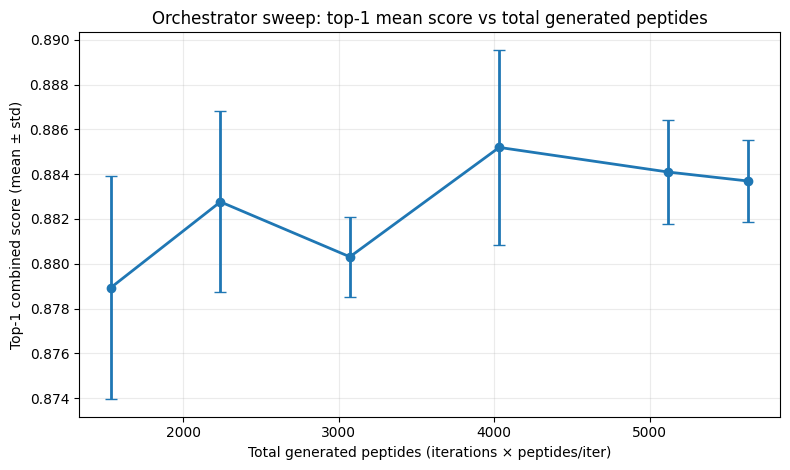

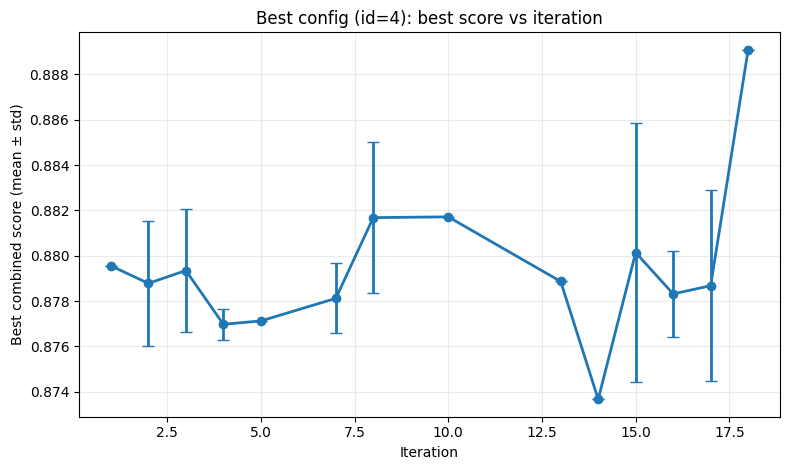

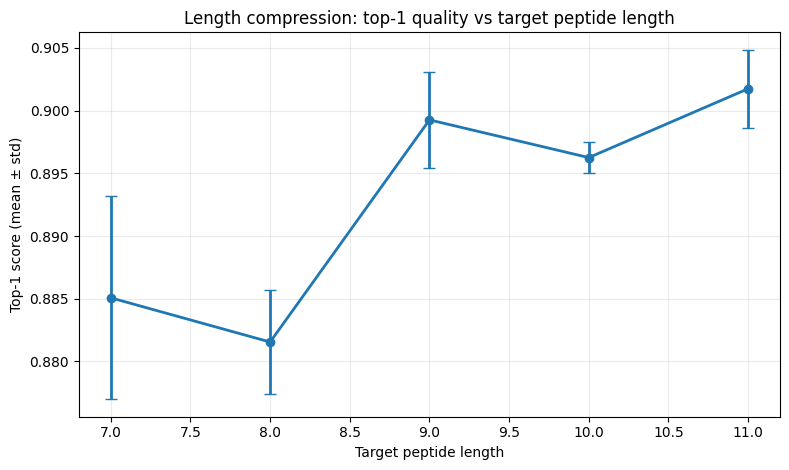

Shortest length with >=98% top-1 retention: L=7 (retention=0.982)


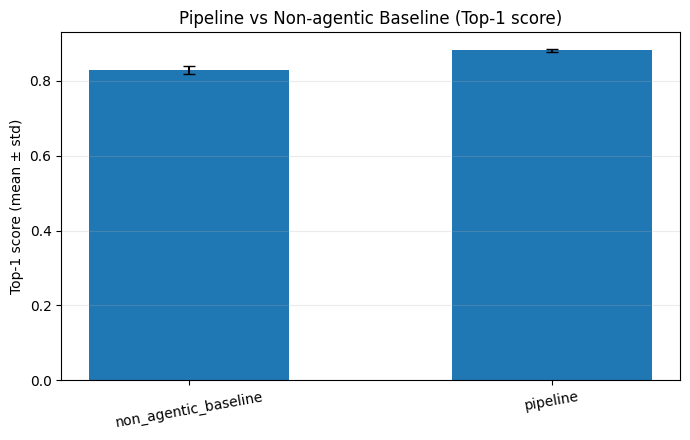

,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std
0,non_agentic_baseline,0.828976,0.010523,0.815642,0.004601,1.0,0.0,1.0,0.0,0.725556,0.071354,4.681429,0.165956
1,pipeline,0.881506,0.003478,0.877094,0.003744,1.0,0.0,1.0,0.0,0.739899,0.087475,4.718008,0.046123


Relevant report figures rendered (strict 2-variable charts).


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 1: top-1 mean score vs total generated peptides (2 vars: x=budget, y=score).
if 'orchestrator_results_df' in globals() and not orchestrator_results_df.empty:
    plot_df = orchestrator_results_df.sort_values('total_generated').copy()
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.errorbar(
        plot_df['total_generated'],
        plot_df['top1_score_mean'],
        yerr=plot_df['top1_score_std'].fillna(0.0),
        marker='o',
        linewidth=2,
        capsize=4,
    )
    ax.set_title('Orchestrator sweep: top-1 mean score vs total generated peptides')
    ax.set_xlabel('Total generated peptides (iterations × peptides/iter)')
    ax.set_ylabel('Top-1 combined score (mean ± std)')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Figure 2: best score vs iteration for the best config (2 vars: x=iteration, y=score).
if 'orchestrator_trace_df' in globals() and not orchestrator_trace_df.empty and 'config_id' in orchestrator_trace_df.columns:
    best_cfg_id = int(orchestrator_results_df.iloc[0]['config_id'])
    trace_best = orchestrator_trace_df[orchestrator_trace_df['config_id'] == best_cfg_id].copy()
    if not trace_best.empty:
        trace_summary = trace_best.groupby('iteration', as_index=False).agg({
            'best_combined_score': ['mean', 'std']
        })
        trace_summary.columns = ['_'.join(c).strip('_') for c in trace_summary.columns]

        fig, ax = plt.subplots(figsize=(8, 4.8))
        ax.errorbar(
            trace_summary['iteration'],
            trace_summary['best_combined_score_mean'],
            yerr=trace_summary['best_combined_score_std'].fillna(0.0),
            marker='o',
            linewidth=2,
            capsize=4,
        )
        ax.set_title(f'Best config (id={best_cfg_id}): best score vs iteration')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Best combined score (mean ± std)')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

# Figure 3: top-1 mean score vs target peptide length (2 vars: x=length, y=score).
if 'length_sweep_summary_df' in globals() and not length_sweep_summary_df.empty:
    ldf = length_sweep_summary_df.sort_values('target_length').copy()
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.errorbar(
        ldf['target_length'],
        ldf['top1_score_mean'],
        yerr=ldf['top1_score_std'].fillna(0.0),
        marker='o',
        linewidth=2,
        capsize=4,
    )
    ax.set_title('Length compression: top-1 quality vs target peptide length')
    ax.set_xlabel('Target peptide length')
    ax.set_ylabel('Top-1 score (mean ± std)')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    if 'top1_retention_vs_original' in ldf.columns:
        feasible = ldf[ldf['top1_retention_vs_original'] >= 0.98]
        if not feasible.empty:
            shortest = feasible.sort_values('target_length').iloc[0]
            print(
                f"Shortest length with >=98% top-1 retention: L={int(shortest['target_length'])} "
                f"(retention={shortest['top1_retention_vs_original']:.3f})"
            )
        else:
            print('No compressed length reached the 98% top-1 retention threshold.')

# Figure 4: pipeline vs baseline for top-1 only (2 vars: x=method, y=score).
if 'comparison_summary_df' in globals() and not comparison_summary_df.empty:
    summary = comparison_summary_df.copy()
    methods = summary['method'].tolist()
    x_pos = np.arange(len(methods))

    top1_mean = summary['top1_score_mean'].values
    top1_std = summary['top1_score_std'].fillna(0.0).values

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(x_pos, top1_mean, yerr=top1_std, capsize=4, width=0.55)
    ax.set_title('Pipeline vs Non-agentic Baseline (Top-1 score)')
    ax.set_ylabel('Top-1 score (mean ± std)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=10)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

display(comparison_summary_df)
print('Relevant report figures rendered (strict 2-variable charts).')

In [13]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Cleanup done.')

Cleanup done.
